In [1]:
import sys
import os

## For Running in Google Colab

In [2]:
%%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    try:
        import ray
    except ImportError:
        # %cd '/content/drive/MyDrive/structure-loss-classification/'
        %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/c/Users/alfredog/OneDrive - SINTEF/data/types/"

## Import Relevant Modules from Structure Loss Classification Package

In [3]:
from models.models import LeNet5, VGG16, ResNet18
from visualization.filters import display_filters
from visualization.display import display_cm
from train.train import get_features
from hyperparameter_tuning.tune import hypertune_classifier, SKLearnHyperParameterTuner
from datasets.datasets import CustomDatasetWrapper
from utils.utils import get_category_names

/home/alfredosg/.envs/sl-ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-05-27 13:54:00,406	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-05-27 13:54:00,763	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-05-27 13:54:00,856	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Sci-Kit Learn Classifiers

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## CU-ML Classifiers

In [5]:
import cuml

In [6]:
from cuml.ensemble import RandomForestClassifier
from cuml.neighbors import KNeighborsClassifier
from cuml.svm import SVC

## Other Packages

In [7]:
from torchvision.models.feature_extraction import get_graph_node_names
from sklearn.metrics import confusion_matrix
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import numpy as np
import json
import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from ray import tune

## Environment Variables

In [8]:
%env RAY_AIR_RICH_LAYOUT=1
%env RAY_AIR_NEW_OUTPUT=1.

env: RAY_AIR_RICH_LAYOUT=1
env: RAY_AIR_NEW_OUTPUT=1.


## Transformations

In [9]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(90),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)
# toTensorAndNormalize = transforms.Compose([
#     transforms.Resize((244, 244)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(90),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
# ])

## Define Classification Task

In [10]:
classification_mode = "all"

In [11]:
task = {
    'binary': 2,
    'only_bad': 3,
    'all': 4
}

num_classes = task[classification_mode]

In [12]:
aux_data = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [13]:
categories = get_category_names(aux_data)

In [14]:
categories

['No Structure\nLoss', 'Diameter\nFluctuations', 'Node Cut', 'Particle Hit']

## Instantiate CNN and Obtain Feature Maps

In [15]:
# model = ResNet18(num_classes=num_classes)
model = VGG16(num_classes=num_classes)
# model = LeNet5(num_classes=num_classes)

model = model.to('cuda')

In [16]:
model.__class__.__name__

'VGG16'

In [17]:
# layers = [e for e in get_graph_node_names(model)[0] if 'convStack.' in e]

if model.__class__.__name__ == 'LeNet5':
    layers = ['convStack.1', 'convStack.2', 'convStack.3',]
    name_layers=['Pooling Layer 1', 'Pooling Layer 2', 'Pooling Layer 3']

elif model.__class__.__name__ == 'VGG16':
    layers = ["convStack.2", "convStack.5", "convStack.10", "convStack.14", "convStack.18"]
    name_layers = ['Pooling layer 1', 'Pooling layer 2', 'Pooling layer 3', 'Pooling layer 4', 'Pooling layer 5',]

elif model.__class__.__name__ == 'ResNet18':
    layers = ['resnet18.maxpool', 'resnet18.avgpool']
    name_layers = ['Pooling Layer 1', 'Pooling Layer 2']

In [18]:
features, labels = get_features(model=model,
                                layers=layers,
                                data_loader=aux_data,
                                device="cuda",
                                classification_mode=classification_mode
                                )

Attempting to load cached features and labels...
Cache not found. Extracting features and labels...
Features and labels extracted and saved to cache.


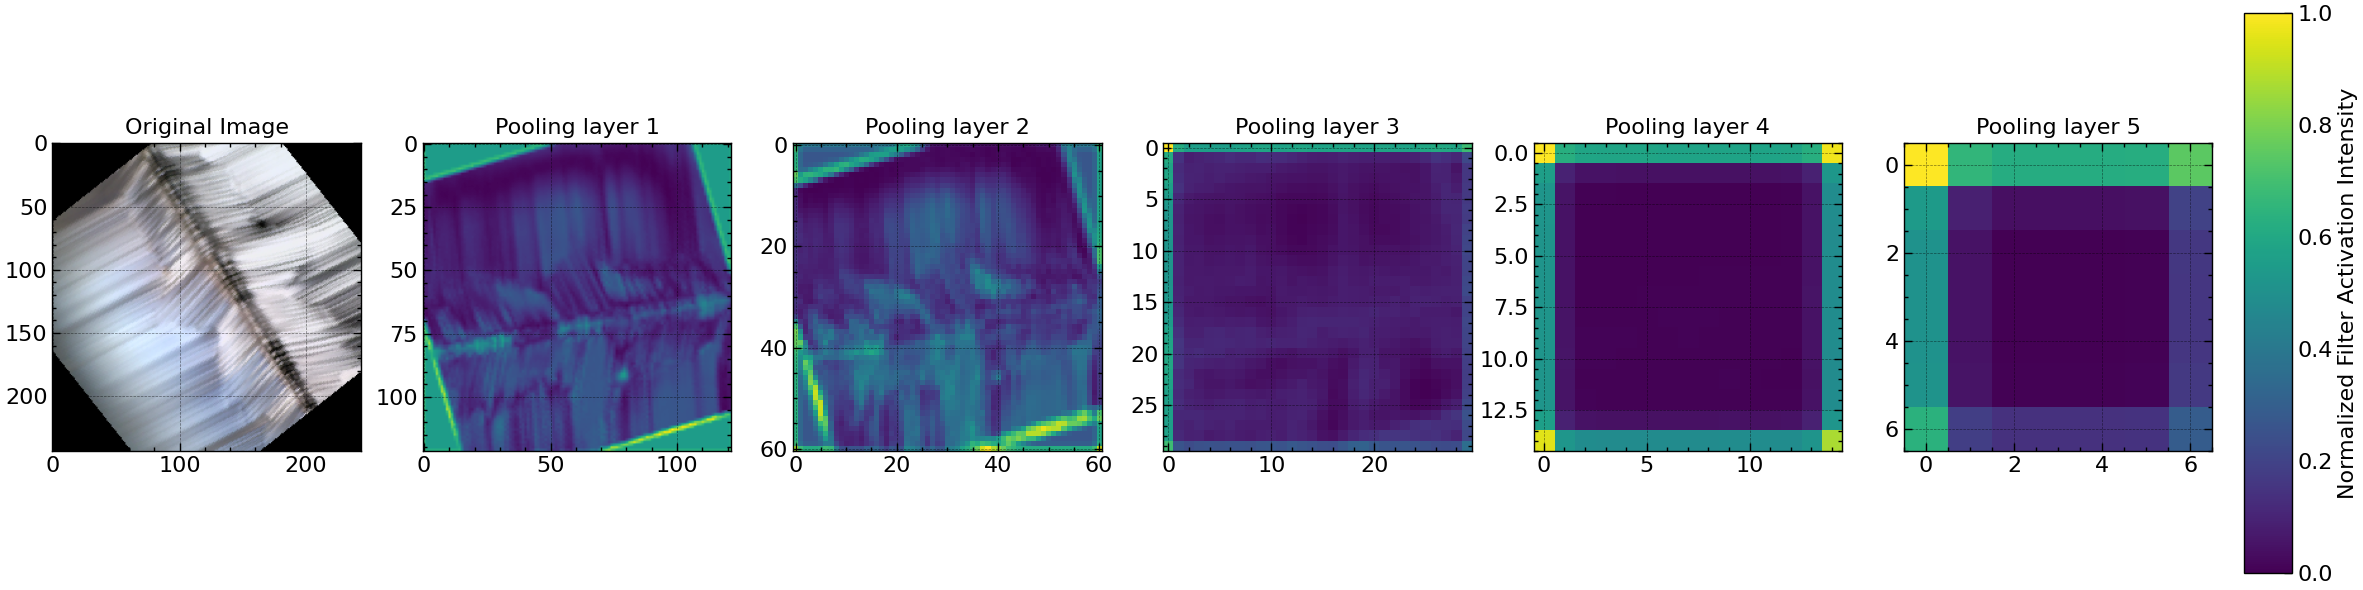

In [19]:
display_filters(features=features,
            img_num=123,
            layers=layers,
            cmap='viridis',
            name_layers=name_layers,
            data=aux_data,
            save=True,
            model_class = model.__class__.__name__
            )

## Process Feature Map for Usage In SciKit-Learn Models

In [20]:
new_features = {}

In [21]:
for layer_name in features:
    new_features[layer_name] = [feature.flatten() for feature in features[layer_name]]

In [22]:
features.keys()

dict_keys(['convStack.2', 'convStack.5', 'convStack.10', 'convStack.14', 'convStack.18'])

In [23]:
feature_index = 1

In [24]:
X = np.array(new_features[layers[feature_index]])
y = np.array(labels)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### PCA

In [26]:
pca = PCA(n_components = 2)

In [27]:
X_pca = X
pca.fit(X_pca)
X_pca = pca.transform(X_pca)

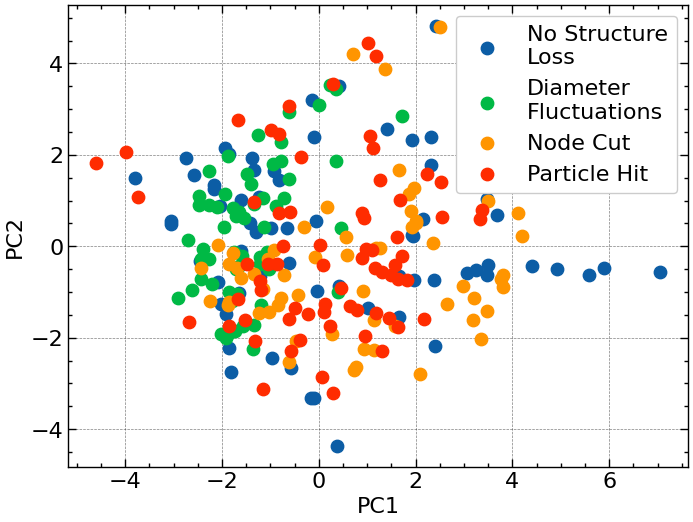

In [28]:
# Plotting
for i, category in enumerate(categories):
    idx = np.array(labels) == i
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=80, label=category)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


In [29]:
pca.explained_variance_ratio_

array([0.11879148, 0.08167662], dtype=float32)

## Main Training

In [30]:
classifiers = {
    "Nearest Neighbors": KNeighborsClassifier,
    "SVM": SVC,
    "Random Forest": RandomForestClassifier,
}

### Hyperparameter Tuning

In [31]:
param_grids = {
    "Nearest Neighbors": {
    'n_neighbors': tune.choice([5, 10, 15, 20]),
    'weights': tune.choice(['uniform']),  # Only use 'uniform'
    'algorithm': tune.choice(['auto',])  # Ensure these are supported
    },
    "SVM": {
        'C': tune.loguniform(1e-3, 1e2),
        'gamma': tune.choice(['scale', 'auto']),
        'kernel': tune.choice(['linear', 'poly', 'rbf'])
    },
    "Random Forest": {
        'max_depth': tune.choice([5, 10, 20]),
        'n_estimators': tune.choice([10, 50, 100, 200]),
        'max_features': tune.choice(['sqrt', 'log2'])
    },
}


In [32]:
for name, clf_class in classifiers.items():
    # Retrieve the parameter grid for the current classifier
    param_grid = param_grids[name]


    config_filename = f"artifacts/hybrid-learning/{model.__class__.__name__}/hyperparameters_{name}_{classification_mode}.json"

    try:
        with open(config_filename, "r") as f:
            best_params = json.load(f)

    except FileNotFoundError:
        # Tune the classifier to find the best parameters
        my_tuner = SKLearnHyperParameterTuner(model = clf_class,
                                              search_space = param_grid,
                                              X= X, y = y,
                                              use_gpu=True)
        best_params = my_tuner.hypertune()

        # Save hp parameters to json
        config_filename = f"artifacts/hybrid-learning/{model.__class__.__name__}/hyperparameters_{name}_{classification_mode}.json"

        with open(config_filename, 'w') as f:
            json.dump(best_params, f, indent=4)

### Training and Evaluation

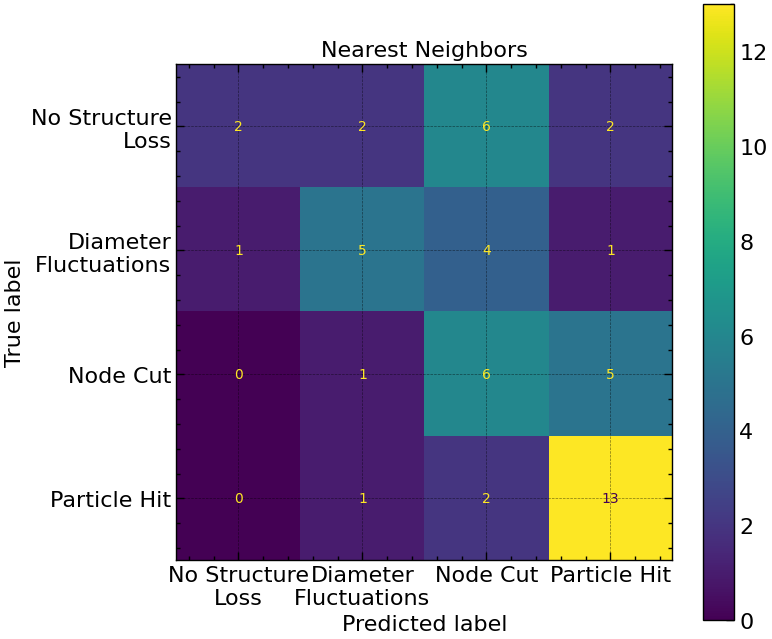

Accuracy of Nearest Neighbors: 0.5098039215686274
########################################


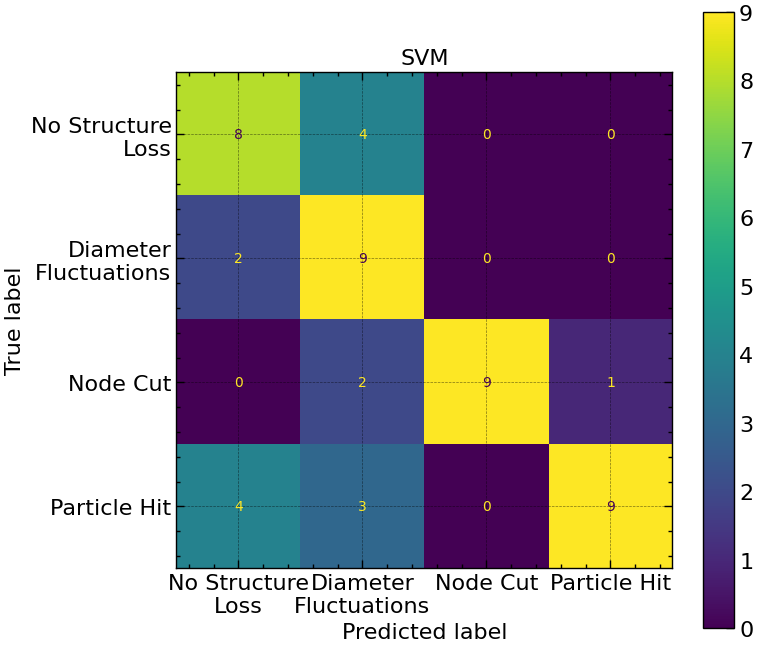

Accuracy of SVM: 0.6862745098039216
########################################


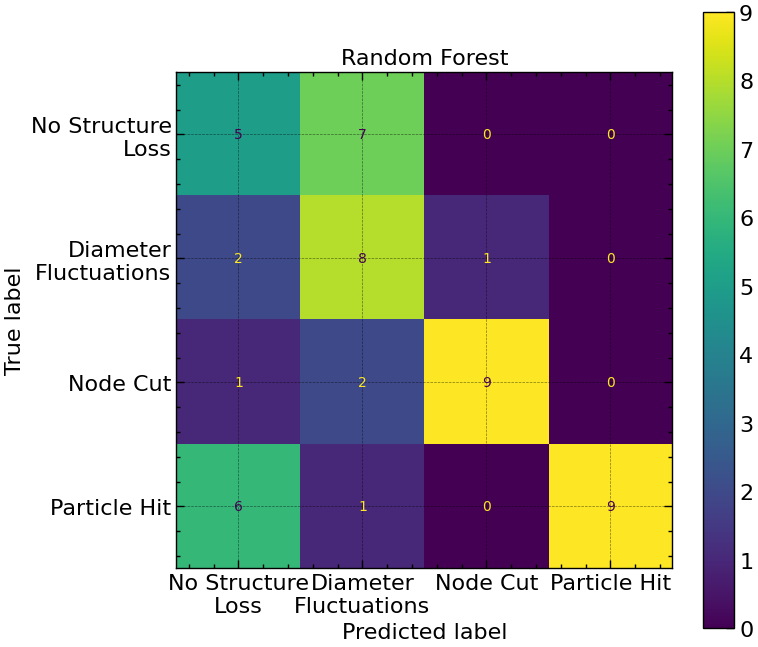

Accuracy of Random Forest: 0.6078431372549019
########################################


In [34]:
for name, clf_class in classifiers.items():
    # Retrieve the parameter grid for the current classifier

    config_filename = f"artifacts/hybrid-learning/{model.__class__.__name__}/hyperparameters_{name}_{classification_mode}.json"

    with open(config_filename, "r") as f:
            best_params = json.load(f)

    # Instantiate the model with the best parameters found
    clf = clf_class(**best_params)

    # Fit the model with the training data
    clf.fit(X_train, y_train)

    # Predict the test set
    y_pred = clf.predict(X_test)

    # Calculate and display the confusion matrix and accuracy
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Assuming display_cm is a function you have to display confusion matrices
    display_cm(cm, categories, name, model, classification_mode, save=False)
    print(f'Accuracy of {name}: {acc}')
    print('########################################')
